In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem

In [3]:
smiles = "CC1(CCC(=C(C1)CN2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC(=C(C=C4)N[C@H](CCN5CCOCC5)CSC6=CC=CC=C6)S(=O)(=O)C(F)(F)F)C7=CC=C(C=C7)Cl)C"
molecule = Chem.MolFromSmiles(smiles)

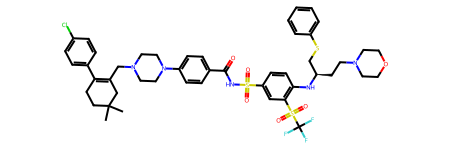

In [4]:
molecule

In [5]:
reaction = AllChem.ReactionFromSmarts("[c:1]-Cl>>[c:1]-C#N")
new_molecule = reaction.RunReactants((molecule,))[0][0]

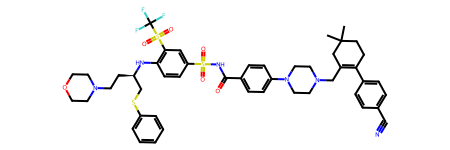

In [6]:
new_molecule

In [7]:
from pathlib import Path

import py3Dmol
from rdkit import Chem

from docking import ligand, receptor, docking, affinity, view

from ipywidgets import interact, IntSlider
import ipywidgets, copy

work_dir = Path("data")
work_dir.mkdir(parents=True, exist_ok=True)

In [8]:
l1 = ligand(work_dir, Chem.MolToSmiles(molecule), 7.4)

Scrub completed.
Summary of what happened:
Input molecules supplied: 1
mols processed: 1, skipped by rdkit: 0, failed: 0
nr isomers (tautomers and acid/base conjugates): 1 (avg. 1.000 per mol)
nr conformers:  1 (avg. 1.000 per isomer, 1.000 per mol)
Input molecules processed: 1, skipped: 0
PDBQT files written: 1
PDBQT files not written due to error: 0
Input molecules with errors: 0


In [9]:
l2 = ligand(work_dir, Chem.MolToSmiles(new_molecule), 7.4)

Scrub completed.
Summary of what happened:
Input molecules supplied: 1
mols processed: 1, skipped by rdkit: 0, failed: 0
nr isomers (tautomers and acid/base conjugates): 1 (avg. 1.000 per mol)
nr conformers:  1 (avg. 1.000 per isomer, 1.000 per mol)
Input molecules processed: 1, skipped: 0
PDBQT files written: 1
PDBQT files not written due to error: 0
Input molecules with errors: 0


In [10]:
rec = receptor(work_dir, "2YXJ", (-9, -16, 11), (25, 31, 18))

@> 2587 atoms and 1 coordinate set(s) were parsed in 0.01s.


Starting mmtbx.reduce2
on Thu Sep 24 16:08:54 2026 by marek

Processing files:
-------------------------------------------------------------------------------

  Found model, e6ab9fa5044cae021a2aa07888c757a7_receptor.pdb

Processing PHIL parameters:
-------------------------------------------------------------------------------

  Adding command-line PHIL:
  -------------------------
    approach=add
    add_flip_movers=True

Final processed PHIL parameters:
-------------------------------------------------------------------------------
  data_manager {
    model {
      file = "e6ab9fa5044cae021a2aa07888c757a7_receptor.pdb"
    }
    default_model = "e6ab9fa5044cae021a2aa07888c757a7_receptor.pdb"
  }
  add_flip_movers = True


Starting job
Writing model output to e6ab9fa5044cae021a2aa07888c757a7_receptorFH.pdb

                       ----------Loading Model----------                       


                      ----------Adding Hydrogens----------                     

Number of hyd

@> 2167 atoms and 1 coordinate set(s) were parsed in 0.01s.


Template padding will be used.
 gasteiger charges will be read from template file 
 

Files written:
  e6ab9fa5044cae021a2aa07888c757a7_receptor.pdbqt <-- static (i.e., rigid) receptor input file
e6ab9fa5044cae021a2aa07888c757a7_receptor.box.txt <-- Vina-style box dimension file
e6ab9fa5044cae021a2aa07888c757a7_receptor.box.pdb <-- PDB file to visualize the grid box


In [11]:
d1 = docking(work_dir, rec, l1, 32)

AutoDock Vina v1.2.7
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [ ]:
d2 = docking(work_dir, rec, l2, 32)

AutoDock Vina v1.2.7
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [ ]:
affinity(work_dir, d1), affinity(work_dir, d2)